# Experiment 08: Range Bound DNN

In this experiment we prototype functions for performing a range analysis on a general DNN.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from prism.networks.dnn import DNN

from verified_computing import intvmath
from verified_computing import taylorfactory

## Construct Taylor Models

We begin by building Taylor models for our activations.


<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-0.07136968] [0.07136968]
<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-1.e-06] [1.e-06]
<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-0.01178506] [0.00508161]


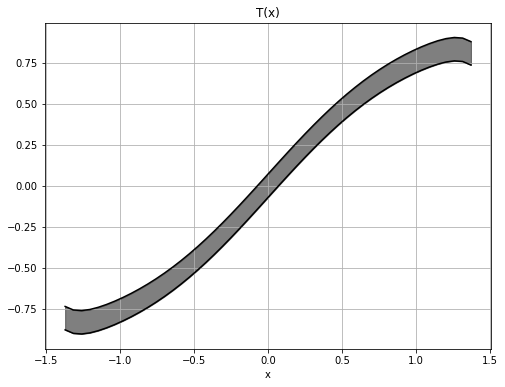

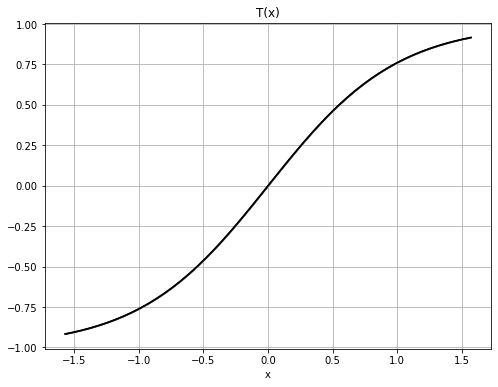

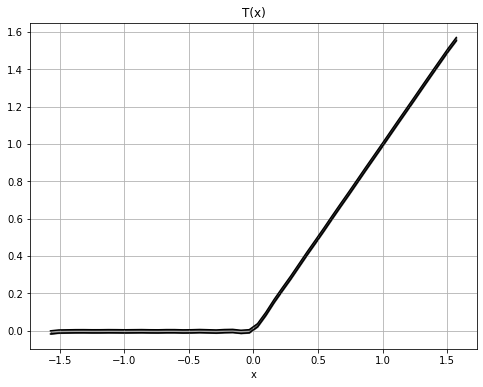

In [4]:
bound = np.pi/2 - 0.2
big_m = 8

# Tanh Taylor model with Taylor polynomials
t_tanh_taylor = taylorfactory.get_taylor_model(
    function_type='tanh_taylor',
    big_m=big_m,
    v_max=bound,
    dps=100,
    silent=True,
    n_brute_points=100,
    tol_final=1e-3
)

t_tanh_taylor.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_tanh_taylor.error.x1, t_tanh_taylor.error.x2)

big_m = 55
bound = np.pi/2
dps = 300

# Tanh Taylor model with AMIE polynomials
t_tanh_amie = taylorfactory.get_taylor_model(
    function_type='tanh',
    big_m=big_m,
    v_max=bound,
    dps=dps,
    silent=True,
    n_brute_points=100,
    tol_final=1e-6
)

t_tanh_amie.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_tanh_amie.error.x1, t_tanh_amie.error.x2)

# ReLU Taylor model with AMIE polynomials
t_relu_amie = taylorfactory.get_taylor_model(
    function_type='relu',
    big_m=big_m,
    v_max=bound,
    dps=dps,
    silent=True,
    n_brute_points=200,
    tol_final=1e-3
)

t_relu_amie.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_relu_amie.error.x1, t_relu_amie.error.x2)

## Create and Train Neural Network

In [5]:
weight_decay = 0.01

relu_net = DNN(
    net_type='relu',
    n_inputs=2, n_hidden=(20,20,20), lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)

tanh_net = DNN(
    net_type='tanh',
    n_inputs=2, n_hidden=(20,20,20), lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)

## Define Range Analysis Functions

Define functions for range analysis:
* Numerically
* Tanh via Taylor
* Tanh via AMIE
* ReLU via AMIE


In [6]:
def range_bound_dnn_numerical(
    target_dnn, x_min, x_max, n_points
):
    """Range bounds a DNN numerically"""
    x_domain = np.random.uniform(
        low=x_min, high=x_max,
        size=(n_points, target_dnn.n_inputs))

    x = x_domain.T

    n_layers = len(target_dnn.net.layers)

    v_min_list = []
    v_max_list = []

    for idx in range(n_layers - 1):
        v = target_dnn.get_w(idx) @ x + target_dnn.get_b(idx)
        x = np.tanh(v)
        v_min_list.append(np.min(v))
        v_max_list.append(np.max(v))

    y_range = target_dnn.get_w(n_layers - 1) @ x + target_dnn.get_b(n_layers - 1)
    y_min = np.min(y_range)
    y_max = np.max(y_range)

    return y_min, y_max, v_min_list, v_max_list



In [7]:
def range_bound_dnn_taylor_model(
    target_dnn, taylor_model,
    x_min, x_max, n_subdomains
):
    """Range bound a DNN via Taylor modeling"""

    x_intervals = intvmath.IntervalColumnVector(
        [intvmath.Interval(x_min, x_max)] * target_dnn.n_inputs
    )

    n_layers = len(target_dnn.net.layers)

    v_list = []

    # Compute initial layers
    for idx in range(n_layers - 1):
        b_vect = target_dnn.get_b(idx)
        w_mat = target_dnn.get_w(idx)
        w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
            w_mat, x_intervals
        )
        v_vect = intvmath.add_real_vector_to_interval_column_vector(
            b_vect, w_times_x
        )
        x_intervals = taylor_model.bound_interval_vector(
            v_vect, n_subdomains
        )
        v_list.append(v_vect)

    # Compute the last layer
    b_vect = target_dnn.get_b(n_layers - 1)
    w_mat = target_dnn.get_w(n_layers - 1)

    w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
        w_mat, x_intervals
    )

    y_range = intvmath.add_real_vector_to_interval_column_vector(
        b_vect, w_times_x
    )

    y_min = y_range.elems[0].x1
    y_max = y_range.elems[0].x2

    return y_min, y_max, v_list


In [8]:
x_min = -0.1
x_max = 0.1

n_subdomains = 50
n_points = 1000

# ----------------------
# Tanh numerical bounds
# ----------------------
(range_min, range_max, v_min_list, v_max_list) = \
    range_bound_dnn_numerical(
        tanh_net, x_min, x_max, n_points
    )
print('Tanh net numerical bounds:')
print(range_min, range_max)
print()
print('v min:')
print(v_min_list)
print('v max:')
print(v_max_list)
print()

(range_min, range_max, v_min_list, v_max_list) = \
    range_bound_dnn_numerical(
        relu_net, x_min, x_max, n_points
    )

print('ReLU net numerical bounds:')
print(range_min, range_max)
print()
print('v min:')
print(v_min_list)
print('v max:')
print(v_max_list)
print()

# -------------------
# Tanh Taylor Bounds
# -------------------
range_min, range_max, v_list = range_bound_dnn_taylor_model(
    tanh_net, t_tanh_taylor,
    x_min, x_max, n_subdomains
)
print('Tanh net Taylor bounds:')
print(range_min, range_max)
print()

# -------------------
# Tanh AMIE Bounds
# -------------------
range_min, range_max, v_list = range_bound_dnn_taylor_model(
    tanh_net, t_tanh_amie,
    x_min, x_max, n_subdomains
)
print('Tanh net AMIE bounds:')
print(range_min, range_max)
print()

# -------------------
# ReLU AMIE Bounds
# -------------------
range_min, range_max, v_list = range_bound_dnn_taylor_model(
    tanh_net, t_relu_amie,
    x_min, x_max, n_subdomains
)
print('ReLU net AMIE bounds:')
print(range_min, range_max)
print()


Tanh net numerical bounds:
0.05983598548891767 0.07264632675136373

v min:
[-0.7802808733213611, -0.3684744428278321, -0.19923979858216623]
v max:
[0.7066397622925689, 0.37555638694499804, 0.42696265804595246]

ReLU net numerical bounds:
-0.09929745068489002 -0.08618994787443762

v min:
[-0.718863678078576, -0.7126848131593445, -0.21463232652393582]
v max:
[0.7582228718580654, 0.45997018957044894, 0.5659483028681939]

Tanh net Taylor bounds:
[-1.26463119] [1.40038671]

Tanh net AMIE bounds:
[-0.39578094] [0.52726732]



c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:704: RuntimeWarning: overflow encountered in power
  interval_result.x1 = interval.x2 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:705: RuntimeWarning: overflow encountered in power
  interval_result.x2 = interval.x1 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:752: RuntimeWarning: overflow encountered in power
  interval_result.x1 = interval.x1 ** integer_exponent_odd
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:753: RuntimeWarning: overflow encountered in power
  interval_result.x2 = interval.x2 ** integer_exponent_odd
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:640: RuntimeWarning: invalid value encountered in multiply
  x1_result_candidate1 = interval_a.x1 * interval

ReLU net AMIE bounds:
[-inf] [inf]

